#  DSCI 235 spr 2024 Assignment 3

Updated 2/27.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Part 1:  Car mileage 

For this exercise we will use the following DataFrame of car mileage data:

In [21]:
df = pd.read_csv("https://github.com/selva86/datasets/raw/master/mpg_ggplot2.csv")
df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


This dataset provides information about each car, including  its manufacturer, model, size of the engine in liters (displ), year, transmission (front wheel drive, rear wheel drive or 4wd), and mileage in city and highway driving.

Using this data answer the following:

* How many compact cars are present in the dataset?  Solve this using `groupby`.  Create a DataFrame that contains all the highly fuel efficient cars (highway mileage of 35 or above) that are not made by Toyota.

In [22]:
# compact cars
df2 = df.groupby("class").size()["compact"]
df2

np.int64(47)

In [23]:
df3 = df[(df["hwy"] >= 35) & (df["manufacturer"] != "toyota")]
df3

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
105,honda,civic,1.8,2008,4,auto(l5),f,25,36,r,subcompact
106,honda,civic,1.8,2008,4,auto(l5),f,24,36,c,subcompact
212,volkswagen,jetta,1.9,1999,4,manual(m5),f,33,44,d,compact
221,volkswagen,new beetle,1.9,1999,4,manual(m5),f,35,44,d,subcompact
222,volkswagen,new beetle,1.9,1999,4,auto(l4),f,29,41,d,subcompact


* What was the city gas mileage of the audi a4 in 2008?  Do that two different ways:  using a Boolean mask, and by using a MultiIndex.

In [24]:
# audi a4
df[(df["manufacturer"] == "audi") & (df["model"] == "a4") & (df["year"] == 2008)]

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
6,audi,a4,3.1,2008,6,auto(av),f,18,27,p,compact


In [25]:
df.set_index(["model", "year", "manufacturer"], inplace=True)



In [26]:
index = pd.IndexSlice

df.loc["a4", 2008, "audi"]["hwy"]

/var/folders/0z/qw4nf_q53f51b99p5x502zrc0000gn/T/ipykernel_50098/298130825.py:3: PerformanceWarning: indexing past lexsort depth may impact performance.
  df.loc["a4", 2008, "audi"]["hwy"]


model  year  manufacturer
a4     2008  audi            31
             audi            30
             audi            27
Name: hwy, dtype: int64

* Using `groupby`, compute the average hwy mileage by manufacturer and plot a  horizontal bar chart of the data.  Have the bars sorted by average mileage.  Use the matplotlib ``barh`` function or the DataFrame ``barh`` method.

In [27]:
# hwy mileage by manufacturer
data = df.groupby("manufacturer")["hwy"].mean().sort_values(ascending=True)
data


manufacturer
land rover    16.500000
lincoln       17.000000
jeep          17.625000
dodge         17.945946
mercury       18.000000
ford          19.360000
chevrolet     21.894737
nissan        24.615385
toyota        24.911765
subaru        25.571429
pontiac       26.400000
audi          26.444444
hyundai       26.857143
volkswagen    29.222222
honda         32.555556
Name: hwy, dtype: float64

Text(0.5, 1.0, 'Average hwy Mileage by Manufacturer')

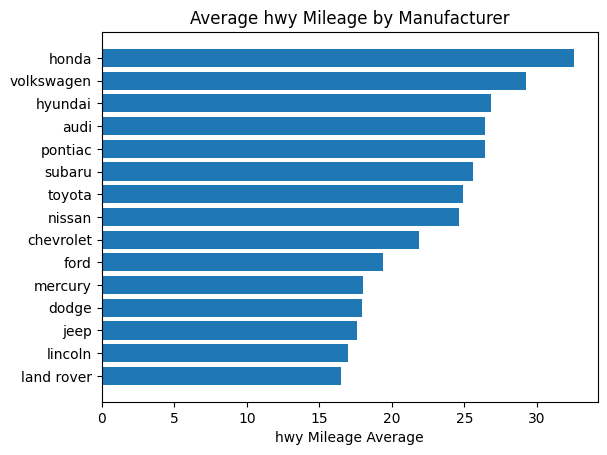

In [28]:
# bar chart with average hwy mileage by manufacturer
plt.barh(data.index, data.values)
plt.xlabel("hwy Mileage Average")
plt.title("Average hwy Mileage by Manufacturer")

* Which class of vehicle has the highest highway MPG on average?  (Use groupby to answer this).

In [29]:
# class of vehicle with highest highway MPG on average
df.groupby("class")["hwy"].mean().idxmax()

'compact'

* Create a DataFrame with car information that includes only those cars for which the manufacturer achieved an average highway MPG of 26 and above. For example, the Audi A4 will be included only on those years for which Audi had achieved a highway MPG of at least 26.

In [30]:
mean_models = df[df.groupby(["manufacturer", "model"])["hwy"].transform("mean") >= 26]
mean_models

displ  cyl       trans drv  cty  hwy fl    class
model  year manufacturer                                                  
a4     1999 audi            1.8    4    auto(l5)   f   18   29  p  compact
            audi            1.8    4  manual(m5)   f   21   29  p  compact
       2008 audi            2.0    4  manual(m6)   f   20   31  p  compact
            audi            2.0    4    auto(av)   f   21   30  p  compact
       1999 audi            2.8    6    auto(l5)   f   16   26  p  compact
...                         ...  ...         ...  ..  ...  ... ..      ...
passat 2008 volkswagen      2.0    4    auto(s6)   f   19   28  p  midsize
            volkswagen      2.0    4  manual(m6)   f   21   29  p  midsize
       1999 volkswagen      2.8    6    auto(l5)   f   16   26  p  midsize
            volkswagen      2.8    6  manual(m5)   f   18   26  p  midsize
       2008 volkswagen      3.6    6    auto(s6)   f   17   26  p  midsize

[100 rows x 8 columns]

* Which vehicle has the largest engine in this dataset?  What is the most common engine displacement?

In [31]:
# engine size
engsize = df.loc[df["displ"].idxmax()]
engsize


/var/folders/0z/qw4nf_q53f51b99p5x502zrc0000gn/T/ipykernel_50098/3198478448.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  engsize = df.loc[df["displ"].idxmax()]


displ  cyl       trans drv  cty  hwy fl    class
model    year manufacturer                                                  
corvette 2008 chevrolet       6.2    8  manual(m6)   r   16   26  p  2seater
              chevrolet       6.2    8    auto(s6)   r   15   25  p  2seater
              chevrolet       7.0    8  manual(m6)   r   15   24  p  2seater

In [32]:
df.reset_index(inplace=True)

In [33]:
most_commmon_dspl = df.groupby("displ")["model"].count().idxmax()
most_commmon_dspl

np.float64(2.0)

## Part 2:  Analyzing annual GDP

Next, we will again look at the dataset of annual Gross Domestic Product (GDP) collected from the 1960's across the world.

In [34]:
gdp = pd.read_csv('http://cs.colostate.edu/~asa/courses/dsci235/spr21/data/worldstats.csv')
gdp.head()

,index,country,year,population,GDP
0,2271,Afghanistan,2015,32526562.0,1.919944e+10
1,2272,Afghanistan,2014,31627506.0,2.005019e+10
2,2273,Afghanistan,2013,30682500.0,2.004633e+10
3,2274,Afghanistan,2012,29726803.0,2.053654e+10
4,2275,Afghanistan,2011,28809167.0,1.793024e+10


* Using `groupby`, find the country that had the largest growth in GDP from 1990 to 2015.

In [35]:
gdp_df = gdp[(gdp["year"] >= 1960) & (gdp["year"] <= 2015)]
gdp_df.head(15)

,index,country,year,population,GDP
0,2271,Afghanistan,2015,32526562.0,1.919944e+10
1,2272,Afghanistan,2014,31627506.0,2.005019e+10
2,2273,Afghanistan,2013,30682500.0,2.004633e+10
3,2274,Afghanistan,2012,29726803.0,2.053654e+10
4,2275,Afghanistan,2011,28809167.0,1.793024e+10
5,2276,Afghanistan,2010,27962207.0,1.593680e+10
6,2277,Afghanistan,2009,27207291.0,1.248694e+10
7,2278,Afghanistan,2008,26528741.0,1.019053e+10
8,2279,Afghanistan,2007,25877544.0,9.843842e+09
9,2280,Afghanistan,2006,25183615.0,7.057598e+09


In [36]:

gdp_df.groupby("country")["GDP"].apply(lambda x: (x.iloc[0]-x.iloc[-1])).idxmax()


'United States'

### Part 3: analyzing movie ratings

Your task is to analyze movie ratings data from the [MovieLens](https://grouplens.org/datasets/movielens/) dataset.
They have multiple datasets, and our focus will be their [1M Dataset](https://grouplens.org/datasets/movielens/1m/) dataset that contains around 1 million movie ratings from 6000 users on 4000 movies.


For the following questions we will focus on two of the MovieLens data files:

"movies.dat", which describes the movies, and 

"ratings.dat" which provides the movie ratings.

The ratings file "ratings.dat" has the following format:

```
user_id::movie_id::rating::time_stamp
```

- user_id is in the range between 1 and 6040 
- movie_id is in th range between 1 and 3952
- Ratings are on a 5-star scale (whole-star ratings only)
- Timestamp is represented in seconds since the epoch as returned by Unix time command.

Movie information is in the file "movies.dat" and is in the following
format:

```
MovieID::Title::Genres
```

- Titles are identical to titles provided by IMDB (including year of release)
- Genres are pipe-separated.

The following commands will read the data into pandas DataFrames:


In [37]:
movies=pd.read_csv('https://www.cs.colostate.edu/~asa/courses/dsci235/spr21/data/movies.dat', sep='::', engine='python', header=None, names=['movie_id', 'title', 'genres'])

In [38]:
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [39]:
ratings=pd.read_csv('https://www.cs.colostate.edu/~asa/courses/dsci235/spr21/data/ratings_subset.dat', sep='::', engine='python', header=None, names=['user_id', 'movie_id', 'rating', 'time_stamp'])
ratings.head()

,user_id,movie_id,rating,time_stamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


Write pandas commands that will answer the following questions:

* The ratings DataFrame identifies movies by their id.  To obtain movie ratings by name, you will need to `merge` the two DataFrames (movies and ratings).  Perform an `inner` merge.  The resulting DataFrame might have fewer rows than the original ratings DataFrame.  Explain why this is happening in this case.

In [40]:
# merge the DataFrames

new_df = pd.merge(movies, ratings, on="movie_id", how="inner")
new_df

,movie_id,title,genres,user_id,rating,time_stamp
0,1,Toy Story (1995),Animation|Children's|Comedy,1,5,978824268
1,1,Toy Story (1995),Animation|Children's|Comedy,6,4,978237008
2,1,Toy Story (1995),Animation|Children's|Comedy,8,4,978233496
3,1,Toy Story (1995),Animation|Children's|Comedy,9,5,978225952
4,1,Toy Story (1995),Animation|Children's|Comedy,10,5,978226474
...,...,...,...,...,...,...
97615,3813,Interiors (1978),Drama,230,4,976824650
97616,3813,Interiors (1978),Drama,319,3,1002940959
97617,3813,Interiors (1978),Drama,333,3,996355393
97618,3813,Interiors (1978),Drama,550,3,976169951


The reason why performing merge on the two data sets using inner join results in fewer rows in the resulting dataframe compared to the ratings dataframe is beceause when doing a inner join it keeps the rows where movie id appears in both dataframes. Therefore not all of the ratings dataframe movie id's were also in the movies data frame, resulting in fewer rows when doing inner join. 

* Which movie has received the largest number of ratings? (In this and other questions, provide titles rather than IDs!

In [41]:
# largest number of ratings
new_df.groupby("title")["rating"].count().idxmax()


'American Beauty (1999)'

* Which movie received the largest number of five star ratings?

In [42]:
# largest number of five star ratings
new_df.groupby("title")["rating"].apply(lambda x: (x == 5).sum()).idxmax()

'American Beauty (1999)'

* Which movie received the highest average rating?

In [43]:
# highest average rating
new_df.groupby("title")["rating"].mean().idxmax()

'Autumn Sonata (1978)'

* In what follows we will define a movie as **highly rated** if at least 50% of its ratings are a "5".  To remove the ability of just a few raters to influence the results, for this task, only consider movies that have received at least 20 ratings.  In this question you have two tasks:
  *  Extract all highly rated movies that received at least 20 ratings.
  *  Among those movies, what is the most common genre?
 
Since pandas does not provide very good support for processing strings you may use a for loop for computing the most common genre, i.e. something like:

```Python
for genres in df['genre'] :
   # do something with genres string
```

Keep in mind that each entry in the genre column can contain multiple genres, so those need to be separated out (recommend using `str.split` for that).

In [44]:
# highly rated movies
high_rated  = new_df[(new_df.groupby("title")["rating"].transform("count")>=20) & (new_df.groupby("title")["rating"].transform(lambda x: (x == 5).mean())>=0.5)]
high_rated

,movie_id,title,genres,user_id,rating,time_stamp
2365,50,"Usual Suspects, The (1995)",Crime|Thriller,5,5,978244205
2366,50,"Usual Suspects, The (1995)",Crime|Thriller,9,4,978225333
2367,50,"Usual Suspects, The (1995)",Crime|Thriller,11,5,978219607
2368,50,"Usual Suspects, The (1995)",Crime|Thriller,13,4,978201724
2369,50,"Usual Suspects, The (1995)",Crime|Thriller,15,4,978197842
...,...,...,...,...,...,...
90321,3469,Inherit the Wind (1960),Drama,549,4,976121503
90322,3469,Inherit the Wind (1960),Drama,564,5,976040652
90323,3469,Inherit the Wind (1960),Drama,610,4,975861145
90324,3469,Inherit the Wind (1960),Drama,611,5,975858360


In [45]:
# most common genre among highly rated movies

count_genre = {}

for genre in high_rated["genres"]:
    genre_list = genre.split("|")
    for i in genre_list:
        if i in count_genre:
            count_genre[i] += 1
        else:
            count_genre[i] = 1

max(count_genre, key=count_genre.get)
    

'Drama'

### Submission

Submit your assignment as a Jupyter notebook via Canvas.  

### Grading 

Grading sheet for assignment 3

```
pandas:  car mileage (50 pts)
  compact cars (10 pts)
  audi a4 (10 pts)
  hwy mileage by manufacturer (10 pts)
  average hwy mileage by manufacturer (10 pts)
  engine size (10 pts)

Analyzing GDP (10 pts)

Analyzing movie rating data (40 pts)
  merge dataframes (10 pts)
  movie with largest number of ratings (10 pts)
  movie with highest average rating (10 pts)
  highly rated movies:
    extracting them (5 pts)
    most common genre among highly rated movies (5 pts)
  
```

Throughout the course, use of for loops is discouraged.  **Points will be taken off for using for loops unless explicitly allowed.**  pandas /NumPy provide tools for accomplishing things without the need for Python loops.